<a href="https://colab.research.google.com/github/Innotech-Manipal-TP26/Ananyaraj2ndYear/blob/main/Week4/PlainCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import time

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

100%|██████████| 170M/170M [00:03<00:00, 43.5MB/s]


In [3]:
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [4]:
class PlainCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Linear(256,10)

    def forward(self,x):

        x = self.features(x)
        x = torch.flatten(x,1)
        x = self.classifier(x)

        return x

In [10]:
def train_model(model, train_loader, val_loader, epochs=20):

    model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=0.003,
        steps_per_epoch=len(train_loader),
        epochs=epochs
    )

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):

        model.train()

        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()

            _, pred = outputs.max(1)
            correct += pred.eq(labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader)
        train_acc = correct / total

        val_acc, val_loss = evaluate(model, val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        gap = train_acc - val_acc

        print(f"Epoch {epoch+1} | Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f} | Gap {gap:.4f}")

    return train_losses, val_losses, train_accs, val_accs

In [6]:
def evaluate(model, loader):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            l = criterion(outputs,labels)
            loss += l.item()

            _,pred = outputs.max(1)

            correct += pred.eq(labels).sum().item()
            total += labels.size(0)

    acc = correct/total

    return acc, loss

In [14]:
plain_model = PlainCNN()

train_losses, val_losses, train_accs, val_accs = train_model(
    plain_model,
    train_loader,
    val_loader,
    epochs=20
)

Epoch 1 | Train Acc 0.4636 | Val Acc 0.5230 | Gap -0.0594
Epoch 2 | Train Acc 0.6110 | Val Acc 0.6112 | Gap -0.0002
Epoch 3 | Train Acc 0.6882 | Val Acc 0.6360 | Gap 0.0522
Epoch 4 | Train Acc 0.7393 | Val Acc 0.7346 | Gap 0.0047
Epoch 5 | Train Acc 0.7771 | Val Acc 0.6914 | Gap 0.0857
Epoch 6 | Train Acc 0.8021 | Val Acc 0.7426 | Gap 0.0595
Epoch 7 | Train Acc 0.8238 | Val Acc 0.7116 | Gap 0.1122
Epoch 8 | Train Acc 0.8424 | Val Acc 0.7918 | Gap 0.0506
Epoch 9 | Train Acc 0.8562 | Val Acc 0.8160 | Gap 0.0402
Epoch 10 | Train Acc 0.8717 | Val Acc 0.8300 | Gap 0.0417
Epoch 11 | Train Acc 0.8822 | Val Acc 0.8508 | Gap 0.0314
Epoch 12 | Train Acc 0.8957 | Val Acc 0.8534 | Gap 0.0423
Epoch 13 | Train Acc 0.9070 | Val Acc 0.8722 | Gap 0.0348
Epoch 14 | Train Acc 0.9204 | Val Acc 0.8794 | Gap 0.0410
Epoch 15 | Train Acc 0.9318 | Val Acc 0.8854 | Gap 0.0464
Epoch 16 | Train Acc 0.9414 | Val Acc 0.8900 | Gap 0.0514
Epoch 17 | Train Acc 0.9522 | Val Acc 0.8986 | Gap 0.0536
Epoch 18 | Train Acc 

In [15]:
test_acc,_ = evaluate(plain_model,test_loader)
print("Test Accuracy:",test_acc)

Test Accuracy: 0.9042


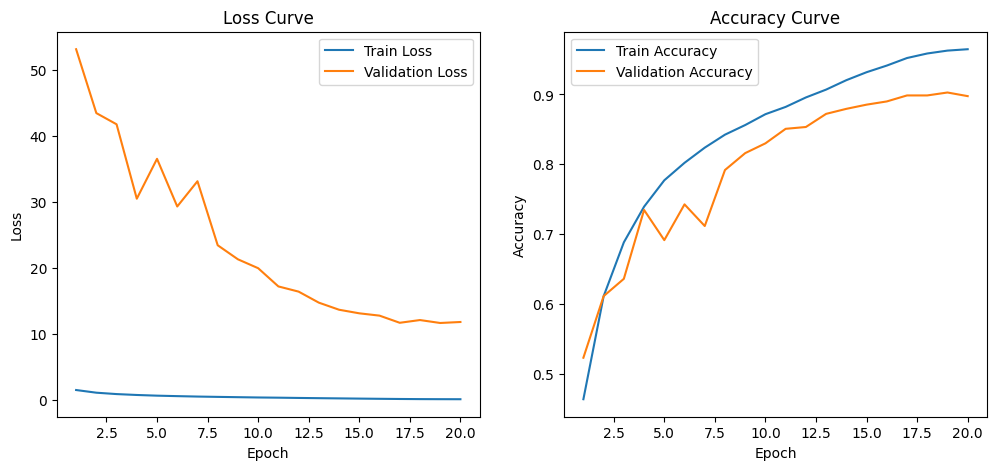

In [16]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()